# Aufgabe 2

## Herleitung der Theoretischen Werte

Der Aufbau für die zweite Aufgabe wurde nach dem folgenden Aufbau aus dem moodle Dokument vorgenommen:
![alt text](Bilder/Spannungsteiler.png "Schaltplan Spannungsteiler")

Die klassische Formel für diesen Spannungsteiler lautet wie folgt:
$$U_{2} = U \cdot \frac{R_{2}}{R_{1}+R_{2}}$$

Wobei U die angelegte Spannung ist, $U_{2}$ die Spannung die über den Widerstand $R_{2}$ abfällt und $R_{1}, R_{2}$ die Widerstände sind. In unserem Fall haben wir jedoch nicht den klassischen Spannungsteiler, sondern an der Stelle von $R_{2}$ sind 2 parallel geschaltete Widerstände $R_{2}$ und $R_{L}$. Wir wissen durch das 2. Kirchhoffsche Gesetz, dass die Spannung $U_{2}$ gleich der Spannung $U_{L}$ ist. Außerdem gilt für die beiden parallelen Widerstände:
$$R_{2||L} = \frac{1}{\frac{1}{R_{2}} + \frac{1}{R_{L}}} = \frac{R_{2}R_{L}}{R_{2} + R_{L}}$$
Das können wir in unsere klassische Formel eingeben und bekommen daraus:
$$U_{L} = U_{2} = U \cdot \frac{R_{2||L}}{R_{1} + R_{2||L}} = U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{R_{1} + \frac{R_{2}R_{L}}{R_{2} + R_{L}}} = U \cdot \frac{\frac{R_{2}R_{L}}{R_{2} + R_{L}}}{\frac{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}{R_{2} + R_{L}}} = U \cdot \frac{R_{2}R_{L}}{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}$$

In unserem Versuch haben wir für $U = 5 V$ angelegt, welche wir nochmal am Board gemessen haben und kleiner Abweichungen gemessen haben. Für $R_{L} = 100 \Omega$ haben wir $U = 4,97V$ gemessen und bei allen anderen $U=4,96V$. Für die Widerstände haben wir $R_{1} = 100 \Omega$ und $R_{2} = 200 \Omega$ gewählt, also wie vorgegeben $R_{1} < R{2}$. Wir haben $R_{L} = 100 \Omega$ als Startzustand gewählt, da $R_{1||2} = \frac{1}{\frac{1}{100 \Omega} + \frac{1}{200 \Omega}} = \frac{200}{3} \Omega$ und da wir $100 \Omega$ Schritte machen wollten, war $100 \Omega$ der nächstbeste Wert.

Für den Graphen sollten wir $U/U_{L}$ darstellen, also wurde noch umgestellt zu:
$$\frac{U}{U_{L}} = \frac{R_{1}R_{2} + R_{1}R_{L} + R_{2}R_{L}}{R_{2}R_{L}}$$

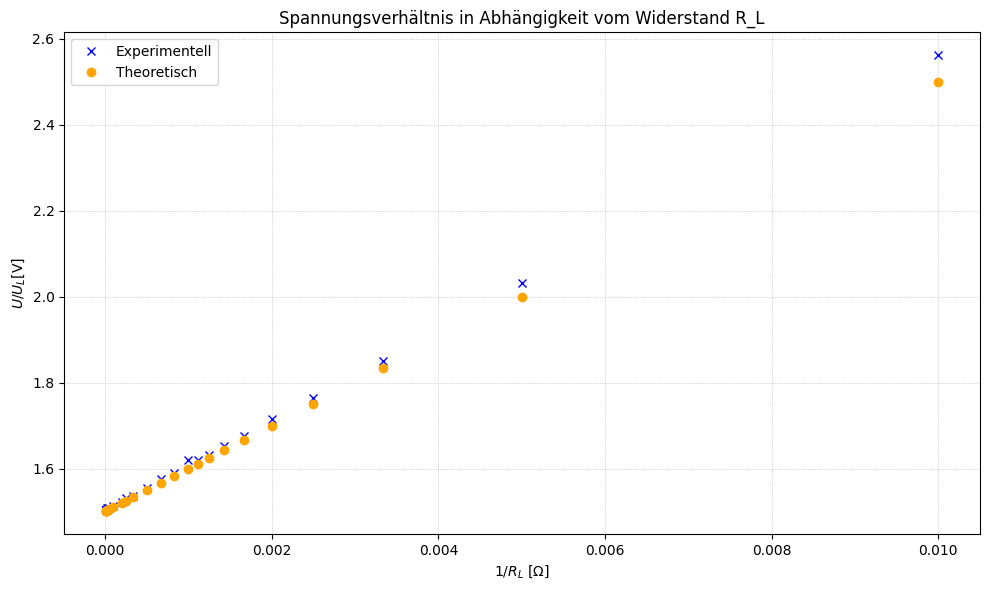

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_2.csv')
df.columns = ['R_L[Ohm]','U[V]','U_L[V]']

# Konstanten definieren
R_1 = 100
R_2 = 200

def U_L(U, R):
    U_L = U * R_2*R/(R_1*R_2 + R_1*R + R_2*R)
    return U_L

df['U_L_theor'] = U_L(df['U[V]'], df['R_L[Ohm]'])
df['U_Verhaelt'] = df['U[V]']/df['U_L[V]']
df['U_theor_Verhaelt'] = df['U[V]']/df['U_L_theor']
df['R_umgekehrt'] = 1/df['R_L[Ohm]']


plt.figure(figsize=(10, 6))
plt.plot(df['R_umgekehrt'], df['U_Verhaelt'],'x', label='Experimentell', color='blue')
plt.plot(df['R_umgekehrt'], df['U_theor_Verhaelt'],'o', label='Theoretisch', color='orange')
plt.xlabel(r'$1/R_L$ [$\Omega$]')
plt.ylabel(r'$U/U_L$[V]')
plt.title('Spannungsverhältnis in Abhängigkeit vom Widerstand R_L')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# $R_1$ und $R_1/R_2$ bestimmen

Für das bestimmmen von $R_1$ und $R_1/R_2$ nehmen wir unsere Werte von oben und geben dem ganzen einen linearen fit. Wir können die Formel von oben auch so umstellen, dass wir mithilfe der Fitparameter die beiden gesuchten Werte bestimmen können. Wenn wir die oben hergeleitete Formel nochmal umstellen, bekommen wir:
$$\frac{U}{U_L} = \frac{R_1}{R_L} + \frac{R_1}{R_2} + 1 = a \cdot \frac{1}{R_L} + b$$
Mit $a = R_1$ und $b = R_1/R_2 + 1$

Theoretischer Fit: Steigung a = 100.000, Achsenabschnitt b = 1.500
Gemessener Fit:     Steigung a = 105.867, Achsenabschnitt b = 1.502


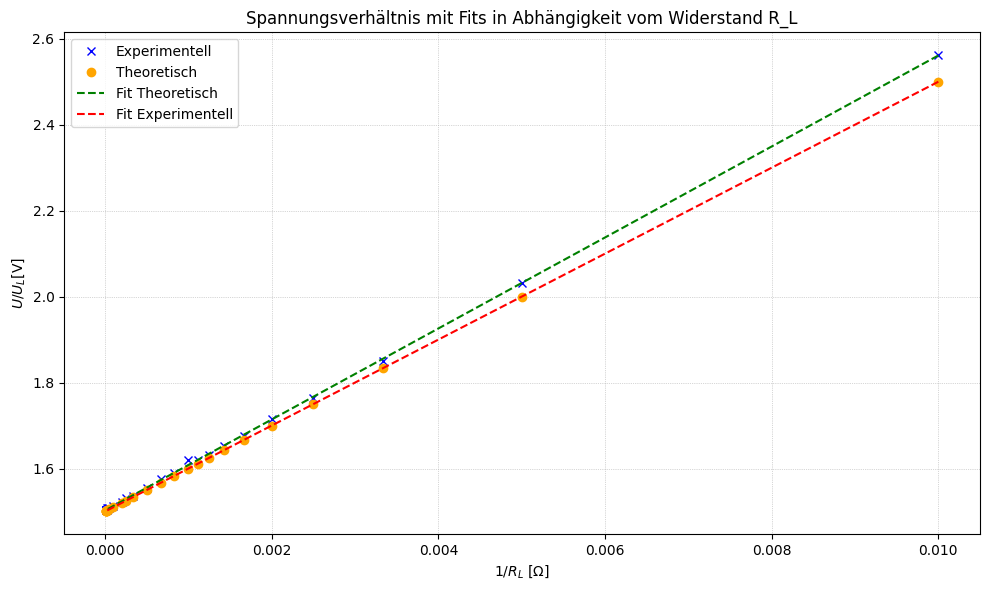

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CSV-Datei laden
df = pd.read_csv('Daten/Daten_Aufgabe_2.csv')
df.columns = ['R_L[Ohm]','U[V]','U_L[V]']

# Konstanten definieren
R_1 = 100
R_2 = 200

def U_L(U, R):
    U_L = U * R_2*R/(R_1*R_2 + R_1*R + R_2*R)
    return U_L

df['U_L_theor'] = U_L(df['U[V]'], df['R_L[Ohm]'])
df['U_Verhaelt'] = df['U[V]']/df['U_L[V]']
df['U_theor_Verhaelt'] = df['U[V]']/df['U_L_theor']
df['R_umgekehrt'] = 1/df['R_L[Ohm]']

U_L_theor_fit = np.polyfit(df['R_umgekehrt'], df['U_theor_Verhaelt'], 1)
U_L_fit = np.polyfit(df['R_umgekehrt'], df['U_Verhaelt'], 1)

a_theor, b_theor = U_L_theor_fit
a_mess, b_mess = U_L_fit
print(f"Theoretischer Fit: Steigung a = {a_theor:.3f}, Achsenabschnitt b = {b_theor:.3f}")
print(f"Gemessener Fit:     Steigung a = {a_mess:.3f}, Achsenabschnitt b = {b_mess:.3f}")



plt.figure(figsize=(10, 6))
plt.plot(df['R_umgekehrt'], df['U_Verhaelt'],'x', label='Experimentell', color='blue')
plt.plot(df['R_umgekehrt'], df['U_theor_Verhaelt'],'o', label='Theoretisch', color='orange')
plt.plot(df['R_umgekehrt'], np.polyval(U_L_fit, df['R_umgekehrt']), label='Fit Theoretisch', color='green', linestyle='--')
plt.plot(df['R_umgekehrt'], np.polyval(U_L_theor_fit, df['R_umgekehrt']), label='Fit Experimentell', color='red', linestyle='--')
plt.xlabel(r'$1/R_L$ [$\Omega$]')
plt.ylabel(r'$U/U_L$[V]')
plt.title('Spannungsverhältnis mit Fits in Abhängigkeit vom Widerstand R_L')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Wir haben nun die Parameter $a$ und $b$ aus unseren Fits, für die Theoretischen Werte sind diese $a = 100$ und $b = 1,5$ und für die Experimentellen Werte sind diese $a = 105,867$ und $b = 1,502$. Für die Theorie sind diese natürlich exakt, da wir $R_1$ und $R_2$ als Werte in unsere Gleichung eingegeben haben und deshalb $a = R_1 = 100 \Omega$ und $b = \frac{R_1}{R_2} + 1 = 1,5 \Rightarrow \frac{R_1}{R_2} = 0,5 = \frac{100}{200}$. Wichtig sind aber die Parameter des Fits für die Experimentell bestimmten Werte. Für diese gilt $R_1 = 105,867 \Omega$ und $\frac{R_1}{R_2} = 0,502$

Die  Abweichungen sind somit beim Wert $R_1$ 5,8% und beim Verhältnis 0,4%.